<a href="https://colab.research.google.com/github/massimilianogasparini-author/creative-loop-dynamics/blob/main/diagrams/creative_loop_vs_model_autophagy_disorder_MAD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

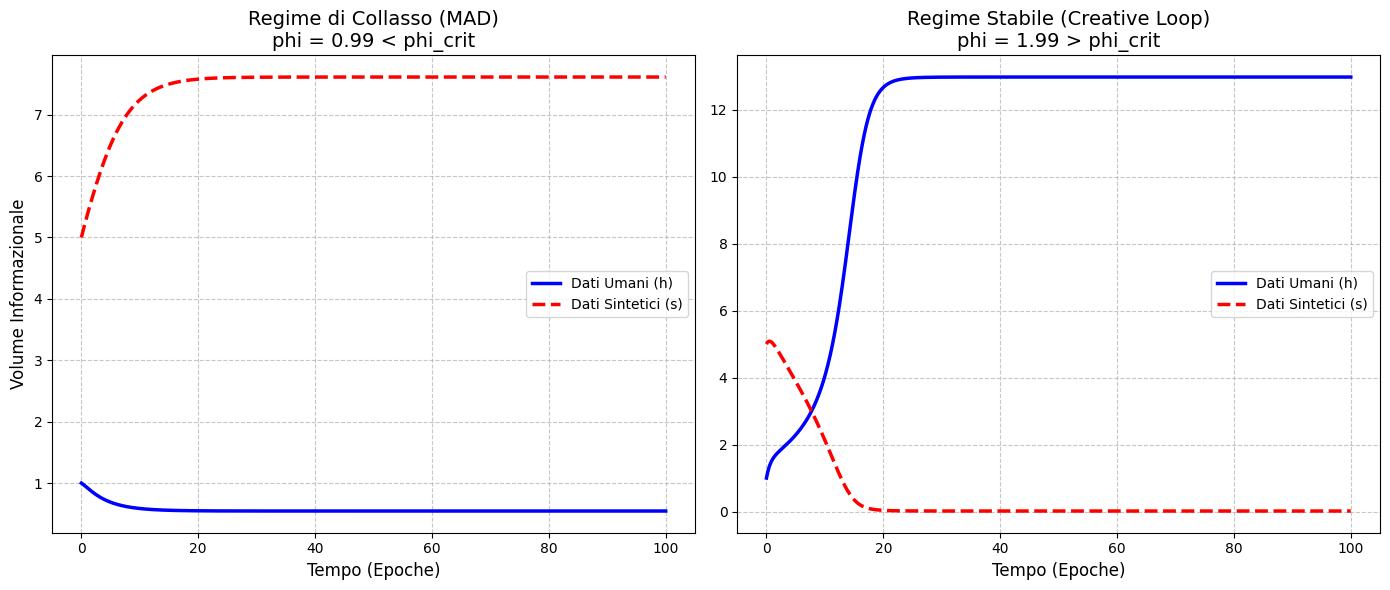

In [1]:
"""
=============================================================================
FILE: creative_loop_vs_model_autophagy_disorder_MAD.ipynb
FRAMEWORK: Creative Loop (DOI: 10.5281/zenodo.19500843)
AUTORE: Massimiliano Gasparini (ORCID: 0009-0004-4216-4852)
DESCRIZIONE: Integrazione numerica e visualizzazione del regime di MAD
=============================================================================
"""
import numpy as np
from scipy.integrate import odeint
from scipy.optimize import fsolve
import matplotlib.pyplot as plt

# Parametri del Modello h-s
alpha, beta, gamma, lambd_, K, Ks = 0.5, 0.3, 0.4, 0.2, 10, 10

# Calcolo analitico in tempo reale della soglia critica di biforcazione
def dphi_dh(h):
    return beta * Ks * np.exp(-(lambd_/gamma)*h) * (1 - (lambd_/gamma)*h) - alpha * (1 - 2*h/K)

h_tau = fsolve(dphi_dh, 1.5)[0]
phi_crit = beta * h_tau * Ks * np.exp(-(lambd_/gamma)*h_tau) - alpha * h_tau * (1 - h_tau/K)

# Definizione del sistema differenziale
def creative_loop_system(y, t, phi):
    h, s = y
    s_safe = max(s, 1e-6)
    dh_dt = alpha * h * (1 - h / K) - beta * h * s + phi
    ds_dt = gamma * s * np.log(Ks / s_safe) - lambd_ * s * h
    return [dh_dt, ds_dt]

t = np.linspace(0, 100, 2000)

# CORREZIONE CRITICA: Condizioni Iniziali
# Impostiamo h=1.0 (Basso volume umano) e s=5.0 (Forte inquinamento sintetico preesistente).
# Questo colloca il sistema sotto forte stress per testare l'efficacia di phi.
y0 = [1.0, 5.0]

# Scenari agganciati alla soglia esatta calcolata
phi_collapse = phi_crit - 0.5  # Sotto la soglia -> La pressione sintetica s=5 vincerà
phi_stable = phi_crit + 0.5    # Sopra la soglia -> L'iniezione salverà il sistema da s=5

sol_collapse = odeint(creative_loop_system, y0, t, args=(phi_collapse,))
sol_stable = odeint(creative_loop_system, y0, t, args=(phi_stable,))

# Generazione dei grafici
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Grafico 1: MAD
ax1.plot(t, sol_collapse[:, 0], 'b-', label='Dati Umani (h)', linewidth=2.5)
ax1.plot(t, sol_collapse[:, 1], 'r--', label='Dati Sintetici (s)', linewidth=2.5)
ax1.set_title(f'Regime di Collasso (MAD)\nphi = {phi_collapse:.2f} < phi_crit', fontsize=14)
ax1.set_xlabel('Tempo (Epoche)', fontsize=12)
ax1.set_ylabel('Volume Informazionale', fontsize=12)
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.7)

# Grafico 2: Creative Loop
ax2.plot(t, sol_stable[:, 0], 'b-', label='Dati Umani (h)', linewidth=2.5)
ax2.plot(t, sol_stable[:, 1], 'r--', label='Dati Sintetici (s)', linewidth=2.5)
ax2.set_title(f'Regime Stabile (Creative Loop)\nphi = {phi_stable:.2f} > phi_crit', fontsize=14)
ax2.set_xlabel('Tempo (Epoche)', fontsize=12)
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()